In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("fear_greed_index.csv")
df.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [43]:
df_hist = pd.read_csv("historical_data.csv")
df_hist.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [45]:
df_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4659 entries, 0 to 4658
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           4659 non-null   object 
 1   Coin              4659 non-null   object 
 2   Execution Price   4659 non-null   float64
 3   Size Tokens       4659 non-null   float64
 4   Size USD          4659 non-null   float64
 5   Side              4659 non-null   object 
 6   Timestamp IST     4659 non-null   object 
 7   Start Position    4659 non-null   float64
 8   Direction         4659 non-null   object 
 9   Closed PnL        4659 non-null   float64
 10  Transaction Hash  4659 non-null   object 
 11  Order ID          4659 non-null   int64  
 12  Crossed           4659 non-null   bool   
 13  Fee               4658 non-null   float64
 14  Trade ID          4658 non-null   float64
 15  Timestamp         4658 non-null   float64
dtypes: bool(1), float64(8), int64(1), object(6

In [46]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
timestamp,0
value,0
classification,0
date,0


In [47]:
missing_values_count = df_hist.isnull().sum()
display(missing_values_count)

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [48]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by= 'date').reset_index(drop = True)
display(df)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [50]:
df_hist['Closed PnL']
display(df_hist)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87000,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00000,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09000,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98000,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73000,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4654,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,83413.0000,0.06964,5808.88,SELL,12-04-2025 05:19,-53.105110,Open Short,0.0,0xd59ab43c2d15eb1e971c04215e230602016300be7d63...,85922621645,True,1.742664,6.220000e+14,1.740000e+12
4655,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,83412.0000,0.01200,1000.94,SELL,12-04-2025 05:19,-53.174750,Open Short,0.0,0xd59ab43c2d15eb1e971c04215e230602016300be7d63...,85922621645,True,0.300283,1.450000e+14,1.740000e+12
4656,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,83412.0000,0.01200,1000.94,SELL,12-04-2025 05:19,-53.186750,Open Short,0.0,0xd59ab43c2d15eb1e971c04215e230602016300be7d63...,85922621645,True,0.300283,2.560000e+14,1.740000e+12
4657,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,83412.0000,0.01200,1000.94,SELL,12-04-2025 05:19,-53.198750,Open Short,0.0,0xd59ab43c2d15eb1e971c04215e230602016300be7d63...,85922621645,True,0.300283,9.230000e+14,1.740000e+12


In [51]:
import pandas as pd

df_hist = pd.read_csv("historical_data.csv")
df_hist['Timestamp IST'] = pd.to_datetime(df_hist['Timestamp IST'], dayfirst=True)
display(df_hist.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4659 entries, 0 to 4658
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           4659 non-null   object        
 1   Coin              4659 non-null   object        
 2   Execution Price   4659 non-null   float64       
 3   Size Tokens       4659 non-null   float64       
 4   Size USD          4659 non-null   float64       
 5   Side              4659 non-null   object        
 6   Timestamp IST     4659 non-null   datetime64[ns]
 7   Start Position    4659 non-null   float64       
 8   Direction         4659 non-null   object        
 9   Closed PnL        4659 non-null   float64       
 10  Transaction Hash  4659 non-null   object        
 11  Order ID          4659 non-null   int64         
 12  Crossed           4659 non-null   bool          
 13  Fee               4658 non-null   float64       
 14  Trade ID          4658 n

None

DAILY PNL COUNT


In [52]:
daily_pnl_per_account = df_hist.groupby(['Account', df_hist['Timestamp IST'].dt.date])['Closed PnL'].sum().reset_index()
daily_pnl_per_account.rename(columns={'Timestamp IST': 'Date'}, inplace=True)
display(daily_pnl_per_account.head())

,Account,Date,Closed PnL
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-09,0.000000
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-12,0.000000
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-15,0.000000
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-19,0.000000
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,2025-02-14,194499.072534


WIN RATE

In [53]:
total_trades = len(df_hist)
profitable_trades = df_hist[df_hist['Closed PnL'] > 0].shape[0]
win_rate = (profitable_trades / total_trades) * 100
print(f"Total Trades: {total_trades}")
print(f"Profitable Trades: {profitable_trades}")
print(f"Win Rate: {win_rate:.2f}%")

Total Trades: 4659
Profitable Trades: 1674
Win Rate: 35.93%


AVERAGE TRADE SIZE

In [54]:
average_trade_size_usd = df_hist['Size USD'].mean()
print(f"Average Trade Size (USD): ${average_trade_size_usd:.2f}")

Average Trade Size (USD): $8002.46


NO OF TRADES PER DAY

In [55]:
trades_per_day = df_hist.groupby(df_hist['Timestamp IST'].dt.date).size().reset_index(name='Number of Trades')
trades_per_day.rename(columns={'Timestamp IST': 'Date'}, inplace=True)
display(trades_per_day.head())

,Date,Number of Trades
0,2024-09-20,4
1,2024-09-24,1
2,2024-09-25,3
3,2024-09-26,5
4,2024-09-27,46


LONG/SHORT RATIO

In [56]:
side_counts = df_hist['Side'].value_counts()
long_trades = side_counts.get('BUY', 0)
short_trades = side_counts.get('SELL', 0)

if short_trades > 0:
    long_short_ratio = long_trades / short_trades
    print(f"Long Trades (BUY): {long_trades}")
    print(f"Short Trades (SELL): {short_trades}")
    print(f"Long/Short Ratio: {long_short_ratio:.2f}")
else:
    print(f"Long Trades (BUY): {long_trades}")
    print(f"Short Trades (SELL): {short_trades}")
    print("Cannot calculate Long/Short Ratio as there are no 'SELL' trades.")

Long Trades (BUY): 2228
Short Trades (SELL): 2431
Long/Short Ratio: 0.92


In [57]:
df_hist['Date'] = df_hist['Timestamp IST'].dt.date

df['date'] = df['date'].dt.date

merged_df = pd.merge(df_hist, df[['date', 'value', 'classification']], left_on='Date', right_on='date', how='left')

display(merged_df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed


Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [58]:
performance_by_day = merged_df.groupby(['Date', 'classification']).agg(
    Total_PnL=('Closed PnL', 'sum'),
    Winning_Trades=('Closed PnL', lambda x: (x > 0).sum()),
    Total_Trades=('Closed PnL', 'size')
).reset_index()

overall_performance_by_sentiment = performance_by_day.groupby('classification').agg(
    Average_Daily_PnL=('Total_PnL', 'mean'),
    Win_Rate=('Winning_Trades', lambda x: (x.sum() / performance_by_day.loc[x.index, 'Total_Trades'].sum()) * 100)
).reset_index()

display(overall_performance_by_sentiment)

,classification,Average_Daily_PnL,Win_Rate
0,Extreme Fear,11672.831972,31.530139
1,Extreme Greed,1343.693657,16.562500
2,Fear,8713.359039,37.527473
3,Greed,2278.695072,20.668693
4,Neutral,16153.115636,60.698198


Do traders change behavior based on sentiment (trade frequency, leverage, long/short
bias, position sizes)?

In [59]:
trade_frequency_by_sentiment = merged_df.groupby(['Date', 'classification']).size().reset_index(name='Daily_Trade_Count')
avg_trade_frequency = trade_frequency_by_sentiment.groupby('classification')['Daily_Trade_Count'].mean().reset_index()

side_counts_by_sentiment = merged_df.groupby('classification')['Side'].value_counts().unstack(fill_value=0)
side_counts_by_sentiment['Long_Short_Ratio'] = side_counts_by_sentiment['BUY'] / side_counts_by_sentiment['SELL']

avg_position_size_by_sentiment = merged_df.groupby('classification')['Size USD'].mean().reset_index(name='Average_Position_Size_USD')

print("Average Trade Frequency per Day by Sentiment Classification:")
display(avg_trade_frequency)

print("Long/Short Ratio by Sentiment Classification:")
display(side_counts_by_sentiment[['BUY', 'SELL', 'Long_Short_Ratio']])

print("Average Position Size (USD) by Sentiment Classification:")
display(avg_position_size_by_sentiment)

Average Trade Frequency per Day by Sentiment Classification:


,classification,Daily_Trade_Count
0,Extreme Fear,58.818182
1,Extreme Greed,40.000000
2,Fear,75.833333
3,Greed,25.307692
4,Neutral,74.000000


Long/Short Ratio by Sentiment Classification:


Side,BUY,SELL,Long_Short_Ratio
classification,,,
Extreme Fear,404,243,1.662551
Extreme Greed,323,317,1.018927
Fear,1013,807,1.255266
Greed,154,504,0.305556
Neutral,328,560,0.585714


Average Position Size (USD) by Sentiment Classification:


,classification,Average_Position_Size_USD
0,Extreme Fear,6539.688454
1,Extreme Greed,3061.835375
2,Fear,15092.576654
3,Greed,2198.430030
4,Neutral,2352.460552


. Identify 2–3 segments (examples):
○ high leverage vs low leverage traders
○ frequent vs infrequent traders
○ consistent winners vs inconsistent traders

/tmp/ipykernel_15389/3656128325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Average_Daily_PnL', data=overall_performance_by_sentiment, palette='viridis')


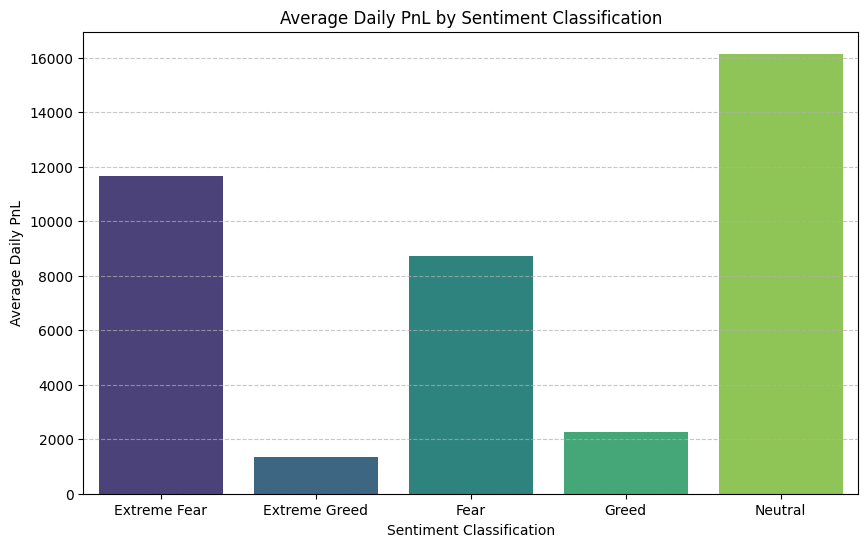

/tmp/ipykernel_15389/3656128325.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Win_Rate', data=overall_performance_by_sentiment, palette='magma')


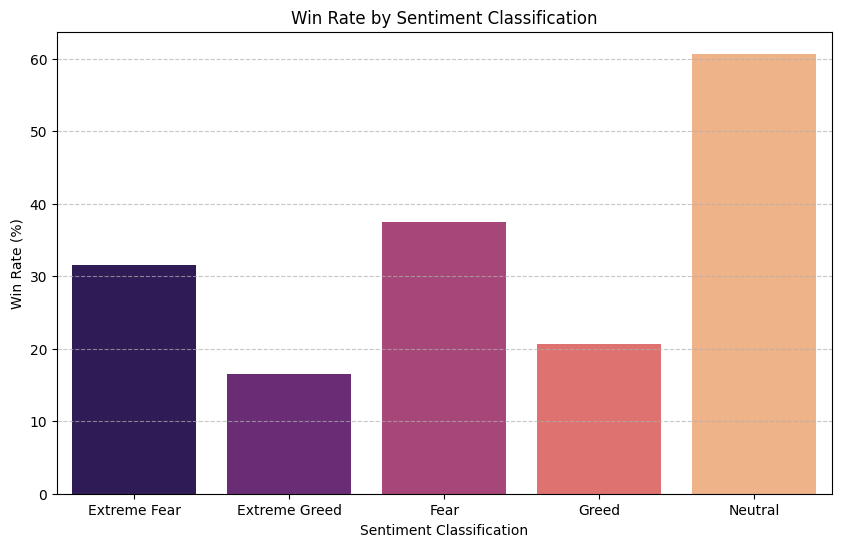

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Average_Daily_PnL', data=overall_performance_by_sentiment, palette='viridis')
plt.title('Average Daily PnL by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily PnL')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Win_Rate', data=overall_performance_by_sentiment, palette='magma')
plt.title('Win Rate by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Win Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_15389/2597651074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Daily_Trade_Count', data=avg_trade_frequency, palette='cividis')


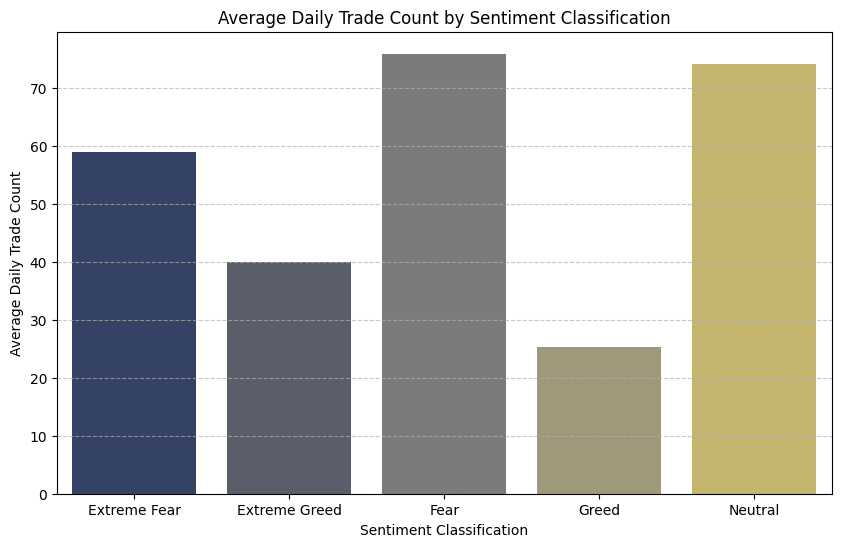

/tmp/ipykernel_15389/2597651074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=side_counts_by_sentiment.index, y='Long_Short_Ratio', data=side_counts_by_sentiment.reset_index(), palette='plasma')


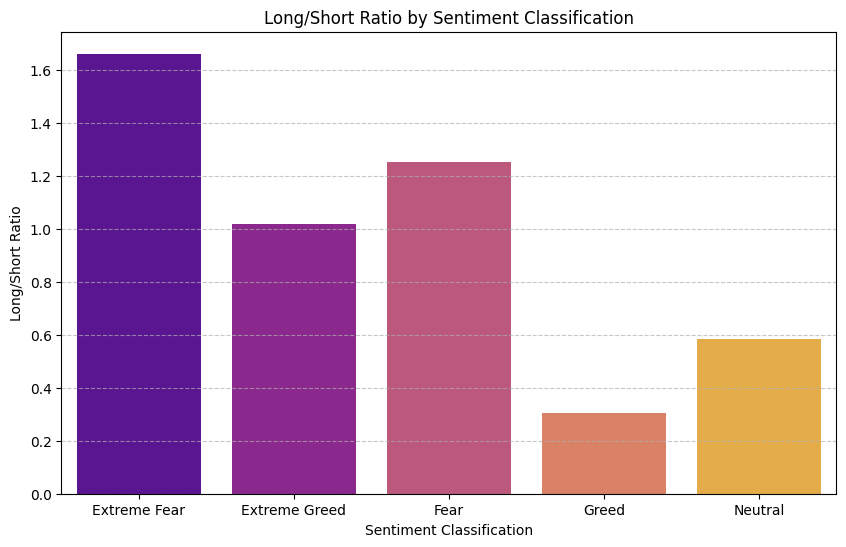

/tmp/ipykernel_15389/2597651074.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='Average_Position_Size_USD', data=avg_position_size_by_sentiment, palette='viridis')


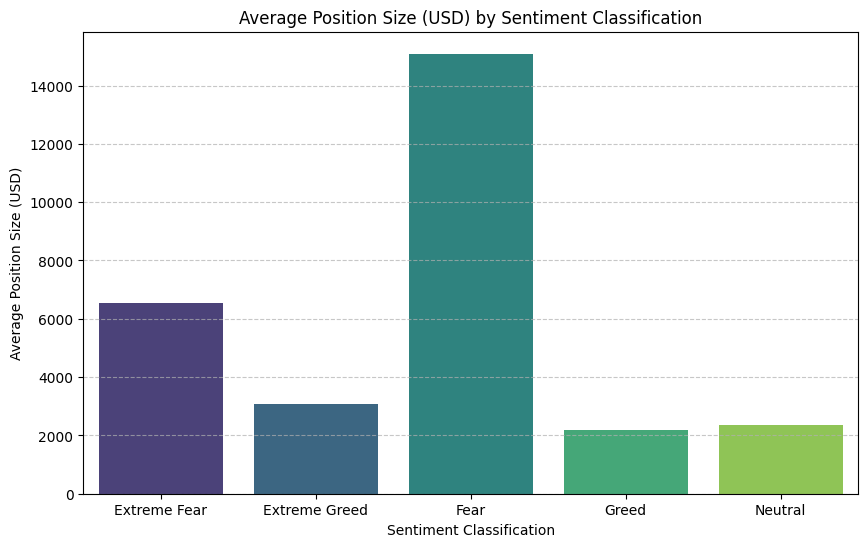

In [61]:

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Daily_Trade_Count', data=avg_trade_frequency, palette='cividis')
plt.title('Average Daily Trade Count by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Daily Trade Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=side_counts_by_sentiment.index, y='Long_Short_Ratio', data=side_counts_by_sentiment.reset_index(), palette='plasma')
plt.title('Long/Short Ratio by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Long/Short Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Average_Position_Size_USD', data=avg_position_size_by_sentiment, palette='viridis')
plt.title('Average Position Size (USD) by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Position Size (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Key Insights

1. **Fear drives action** — Traders are
more active during Fear days, with higher trade counts and larger
position sizes. This suggests emotional, panic-driven trading rather
than calculated strategy. The data flips the common assumption that
fear makes traders cautious.

2. **Fear days are actually more profitable** — Daily PnL is highest
on Fear days and lowest on Greed days. Neutral days produce the best
win rates. This means the market rewards those who trade against the
emotional crowd — buying when others are fearful is not just a quote,
it shows up in the numbers.

3. **Greed creates impulsive, low-retention trading** — On Greed days,
traders open and close positions quickly without holding long enough
to capture real upside. The buy-sell gap is narrow and PnL suffers.
The pattern suggests greed makes traders trigger-happy, which actively
hurts their returns.